# Imports

In [1]:
import importlib
import sys

# performance imports for torch: torch kernel uses one core only.
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["TORCH_NUM_THREADS"] = "1" 

import torch

sys.path.insert(0, '..')
sys.path.insert(0, '../..')
sys.path.insert(0, '../../..')

# Data

### Load Data Files

In [2]:
# Path to your pickle file (saved with torch.save)
file_path_train = '../../../../encoded_data_v2/BPIC17/bpic17_all_5_train.pkl'
# Load the dataset using torch.load
bpic17_train_dataset = torch.load(file_path_train, weights_only=False)

# Path to your pickle file (saved with torch.save)
file_path_val = '../../../../encoded_data_v2/BPIC17/bpic17_all_5_val.pkl'
# Load the dataset using torch.load
bpic17_val_dataset = torch.load(file_path_val, weights_only=False)

### Train Data Insights

In [3]:
# Helpdesk dataset dynamic categories, features:
bpic17_all_categories = bpic17_train_dataset.all_categories

bpic17_all_categories_cat = bpic17_all_categories[0]
# print(helpdesk_all_categories_cat)
bpic17_all_categories_num = bpic17_all_categories[1]
# print(helpdesk_all_categories_num)
for i, cat in enumerate(bpic17_all_categories_cat):
     print(f"BPIC17 dynamic categorical feature: {cat[0]}, Index position in categorical data list: {i}")
     print(f"BPIC17 amount of category labels: {cat[1]}")
print('\n')    
for i, num in enumerate(bpic17_all_categories_num):
     print(f"BPIC17 dynamic numerical feature: {num[0]}, Index position in categorical data list: {i}")
     print(f"BPIC17 amount of numerical: {num[1]}")
print('\n')
     
# Helpdesk dataset static categories, features:
bpic17_all_stat_categories = bpic17_train_dataset.all_static_categories

bpic17_all_stat_categories_cat = bpic17_all_stat_categories[0]
# print(helpdesk_all_stat_categories_cat)
bpic17_all_stat_categories_num = bpic17_all_stat_categories[1]
# print(helpdesk_all_stat_categories_num)
for i, cat in enumerate(bpic17_all_stat_categories_cat):
     print(f"BPIC17 static categorical feature: {cat[0]}, Index position in categorical data list: {i}")
     print(f"BPIC17 amount of category labels: {cat[1]}")
print('\n')    
for i, num in enumerate(bpic17_all_stat_categories_num):
     print(f"BPIC17 static numerical feature: {num[0]}, Index position in categorical data list: {i}")
     print(f"BPIC17 amount of numerical: {num[1]}")  


BPIC17 dynamic categorical feature: concept:name, Index position in categorical data list: 0
BPIC17 amount of category labels: 28
BPIC17 dynamic categorical feature: lifecycle:transition, Index position in categorical data list: 1
BPIC17 amount of category labels: 9
BPIC17 dynamic categorical feature: org:resource, Index position in categorical data list: 2
BPIC17 amount of category labels: 151


BPIC17 dynamic numerical feature: case_elapsed_time, Index position in categorical data list: 0
BPIC17 amount of numerical: 1
BPIC17 dynamic numerical feature: event_elapsed_time, Index position in categorical data list: 1
BPIC17 amount of numerical: 1
BPIC17 dynamic numerical feature: day_in_week, Index position in categorical data list: 2
BPIC17 amount of numerical: 1
BPIC17 dynamic numerical feature: seconds_in_day, Index position in categorical data list: 3
BPIC17 amount of numerical: 1


BPIC17 static categorical feature: case:LoanGoal, Index position in categorical data list: 0
BPIC17 am

### Input Features for Encoder and Decoder

In [4]:
# Create lists with name of Encoder features (input) and decoder features (input & output)
# Encoder features:
enc_feat_cat = []
enc_feat_num = []
for cat in bpic17_all_categories_cat:
    enc_feat_cat.append(cat[0])
for num in bpic17_all_categories_num:
    enc_feat_num.append(num[0])
enc_feat = [enc_feat_cat, enc_feat_num]
print("Input features encoder: ", enc_feat)

# Static encoder features:
stat_enc_feat_cat = []
stat_enc_feat_num = []
for cat in bpic17_all_stat_categories_cat:
     stat_enc_feat_cat.append(cat[0])
for num in bpic17_all_stat_categories_num:
     stat_enc_feat_num.append(num[0])
stat_enc_feat = [stat_enc_feat_cat, stat_enc_feat_num]
print("Input features static encoder: ", stat_enc_feat)

# Decoder features:
dec_feat_cat = ['concept:name']
dec_feat_num = ['case_elapsed_time', 'event_elapsed_time']
dec_feat = [dec_feat_cat, dec_feat_num]
print("Features decoder: ", dec_feat)

Input features encoder:  [['concept:name', 'lifecycle:transition', 'org:resource'], ['case_elapsed_time', 'event_elapsed_time', 'day_in_week', 'seconds_in_day']]
Input features static encoder:  [['case:LoanGoal', 'case:ApplicationType', 'Accepted', 'Selected'], ['case:RequestedAmount', 'FirstWithdrawalAmount', 'NumberOfTerms', 'MonthlyCost', 'CreditScore']]
Features decoder:  [['concept:name'], ['case_elapsed_time', 'event_elapsed_time']]


# Model

In [5]:
import model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model
importlib.reload(model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model)
from model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM

# Prediction decoder output sequence length
seq_len_pred = bpic17_train_dataset.min_suffix_size

# Size hidden layer
hidden_size = 128

# Number of cells
num_layers = 4

# Fixed Dropout probability 
# Experiment with different values but be carefull with exploiting gradients:
dropout = 0.1

# Encoder Decoder model initialization
model = DropoutUncertaintyEncoderDecoderLSTM(data_set_categories=bpic17_all_categories,
                                             enc_feat=enc_feat,
                                             dec_feat=dec_feat,
                                             seq_len_pred=seq_len_pred,
                                             hidden_size=hidden_size,
                                             num_layers=num_layers,
                                             dropout=dropout,
                                             # static attributes
                                             static_data_set_categories=bpic17_all_stat_categories,
                                             static_enc_feat=stat_enc_feat
                                             )

Dynamic data set categories:  ([('concept:name', 28, {'A_Accepted': 1, 'A_Cancelled': 2, 'A_Complete': 3, 'A_Concept': 4, 'A_Create Application': 5, 'A_Denied': 6, 'A_Incomplete': 7, 'A_Pending': 8, 'A_Submitted': 9, 'A_Validating': 10, 'EOS': 11, 'O_Accepted': 12, 'O_Cancelled': 13, 'O_Create Offer': 14, 'O_Created': 15, 'O_Refused': 16, 'O_Returned': 17, 'O_Sent (mail and online)': 18, 'O_Sent (online only)': 19, 'W_Assess potential fraud': 20, 'W_Call after offers': 21, 'W_Call incomplete files': 22, 'W_Complete application': 23, 'W_Handle leads': 24, 'W_Personal Loan collection': 25, 'W_Shortened completion ': 26, 'W_Validate application': 27}), ('lifecycle:transition', 9, {'EOS': 1, 'ate_abort': 2, 'complete': 3, 'resume': 4, 'schedule': 5, 'start': 6, 'suspend': 7, 'withdraw': 8}), ('org:resource', 151, {'EOS': 1, 'User_1': 2, 'User_10': 3, 'User_100': 4, 'User_101': 5, 'User_102': 6, 'User_103': 7, 'User_104': 8, 'User_105': 9, 'User_106': 10, 'User_107': 11, 'User_108': 12, 'Us

# Loss Object Creation

In [6]:
import loss.losses
importlib.reload(loss.losses)
from loss.losses import Loss

loss_obj = Loss()

# Training Configuration

In [7]:
import trainer.trainer
importlib.reload(trainer.trainer)
from trainer.trainer import Trainer
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter(comment="Full_BPIC17_grad")

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Start learning rate
learning_rate = 1e-5
weight_decay = 0

# Optimizer and Scheduler
optimizer = torch.optim.AdamW(params=model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=15, min_lr=1e-8)

# Epochs
num_epochs = 100

# Batches
batch_size = 256

# lambda for L2 (weight, bias, dropout) regularization
# regularization_term = 1.0/(2.0*batch_size)
regularization_term = 1e-4

# shuffle data
shuffle = True

# teacher forcing
max_teacher_forcing_value = 1.0
min_teacher_forcing_value = 0.0

optimize_values = {"regularization_term":regularization_term,
                   "optimizer":optimizer,
                   "scheduler": scheduler,
                   "epochs":num_epochs,
                   "mini_batches":batch_size,
                   "shuffle": shuffle,
                   "min_teacher_forcing_value":min_teacher_forcing_value,
                   "max_teacher_forcing_value":max_teacher_forcing_value}

suffix_data_split_value = bpic17_train_dataset.min_suffix_size
print("Train seq length: ", suffix_data_split_value)

# GradNorm parameter: 
use_gradnorm = True
# use_gradnorm = False
# task to be balanced for teacher forcing
number_tasks = len(dec_feat[0]) + len(dec_feat[1])
# Grdanorm hyperparams
# alpha: tasks/ alpha value (rule of thumb): 2-3: 1.0-1.5, 4-6: 0.7-1.0, 7-10: 0.4-0.7
# Formula approx: 2/sqrt(tasks)
gn_alpha = 1.5
# learning rate: Adjust relative to model learning rate.
gn_learning_rate = 1e-4

gradNorm = {"use_gradnorm":use_gradnorm,
            "number_tasks": number_tasks,
            "gn_alpha":gn_alpha,
            "gn_learning_rate": gn_learning_rate}
# gradNorm = None

trainer = Trainer(device=device,
                  model=model,
                  data_train=bpic17_train_dataset,
                  data_val=bpic17_val_dataset,
                  loss_obj=loss_obj,
                  log_normal_loss_num_feature = [],
                  optimize_values=optimize_values,
                  suffix_data_split_value=suffix_data_split_value,
                  writer=writer,
                  gradnorm_values=gradNorm,
                  save_model_n_th_epoch = 1,
                  saving_path = 'BPIC17_full_grad_norm_new_v2.pkl')

# Train the model:
# - use stattics: (tensor) tensor of seperate encoded static attributes which is merged with dynmaics beforehand
# - use zero padd masking: (True) mask the left padded zeros in the encoder
# - use EOS padd masking: (True) mask the right padded unwanted EOS tokens in the loss
train_attenuated_losses, val_losses, val_attenuated_losses = trainer.train_model(use_statics=True,
                                                                                 use_zero_padd_masking=True,
                                                                                 use_eos_padd_masking=True)

Train seq length:  5
Device:  cuda
Model:  DropoutUncertaintyEncoderDecoderLSTM(
  (embeddings_enc): ModuleList(
    (0): Embedding(28, 10)
    (1): Embedding(9, 5)
    (2): Embedding(151, 27)
  )
  (embeddings_static_enc): ModuleList(
    (0): Embedding(15, 7)
    (1-3): 3 x Embedding(3, 3)
  )
  (encoder): DropoutUncertaintyLSTMEncoder(
    (embeddings): ModuleList(
      (0): Embedding(28, 10)
      (1): Embedding(9, 5)
      (2): Embedding(151, 27)
    )
    (static_embeddings): ModuleList(
      (0): Embedding(15, 7)
      (1-3): 3 x Embedding(3, 3)
    )
    (input_proj): Linear(in_features=67, out_features=128, bias=True)
    (layernorm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (act): ReLU()
    (first_layer): DropoutUncertaintyLSTMCell(
      (Wi): Linear(in_features=128, out_features=128, bias=True)
      (Ui): Linear(in_features=128, out_features=128, bias=True)
      (Wf): Linear(in_features=128, out_features=128, bias=True)
      (Uf): Linear(in_features=1

Epoch [1/100], Learning Rate: 1e-05, Teacher forcing ratio: 1.0
Training: Avg Attenuated Training Loss: 2.4763


Validation: Avg Standard Validation Loss: 3.5222
Validation: Avg Attenuated Validation Loss: 2.1327
Validation Loss for Scheduler: 3.5222
saving model


Epoch [2/100], Learning Rate: 1e-05, Teacher forcing ratio: 0.98
Training: Avg Attenuated Training Loss: 0.4603


Validation: Avg Standard Validation Loss: 3.3669
Validation: Avg Attenuated Validation Loss: 1.8433
Validation Loss for Scheduler: 3.3669
saving model


...

Validation: Avg Standard Validation Loss: 2.3282
Validation: Avg Attenuated Validation Loss: 8.3926
Validation Loss for Scheduler: 2.3282
saving model


Epoch [99/100], Learning Rate: 1e-05, Teacher forcing ratio: 0.0
Training: Avg Attenuated Training Loss: 0.1863


Validation: Avg Standard Validation Loss: 2.3474
Validation: Avg Attenuated Validation Loss: 6.4059
Validation Loss for Scheduler: 2.3474
saving model


Epoch [100/100], Learning Rate: 1e-05, Teacher forcing ratio: 0.0
Training: Avg Attenuated Training Loss: 0.1979


Validation: Avg Standard Validation Loss: 2.3647
Validation: Avg Attenuated Validation Loss: 4.4943
Validation Loss for Scheduler: 2.3647
saving model
Training complete.
Model saved to path: BPIC17_full_grad_norm_new_v2.pkl


# Training Visualization

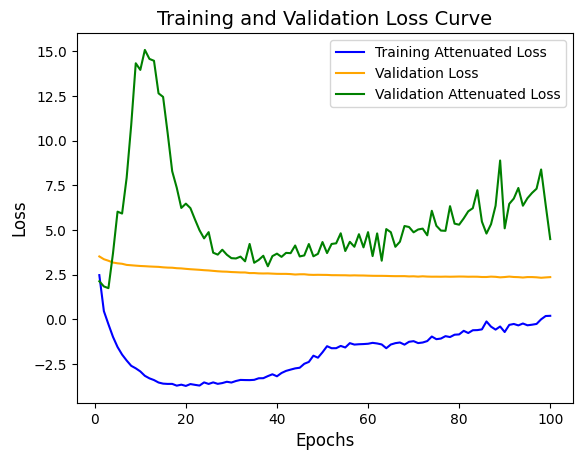

In [8]:
import matplotlib.pyplot as plt

# After training is finished, plot the loss curves
plt.plot(range(1, num_epochs+1), train_attenuated_losses, label='Training Attenuated Loss', color='blue')
plt.plot(range(1, num_epochs+1), val_losses, label='Validation Loss', color='orange')
plt.plot(range(1, num_epochs+1), val_attenuated_losses, label='Validation Attenuated Loss', color='green')
# Labeling x and y axes
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
# Adding title
plt.title('Training and Validation Loss Curve', fontsize=14)
# Adding legend
plt.legend()
# Show the plot
plt.show()